<a href="https://colab.research.google.com/github/upparivijay/ICRTACM_2025_WEBSITE-/blob/main/LoanTap_Case_Study_Final_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
# libraries to analyze data
import numpy as np
import pandas as pd

# libraries to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.pipeline import make_pipeline

from imblearn.over_sampling import SMOTE

In [101]:
# read the file into a pandas dataframe
customer_df = pd.read_csv('/content/logistic_regression.csv')
df = customer_df

In [102]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [104]:
df.shape

(396030, 27)

#Number of nan/null values in each column

In [105]:
df.isna()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396025,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
396026,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
396027,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
396028,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [106]:
df.nunique()

,0
loan_amnt,1397
term,2
int_rate,566
installment,55706
grade,7
sub_grade,35
emp_title,173105
emp_length,11
home_ownership,6
annual_inc,27197


In [107]:
# Duplicate entries

In [108]:
df.duplicated().value_counts()

,count
False,396030


In [109]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


#Insight

1. There are 396030 entries with 27 columns
2. There are no duplicates
3. Based on the number of unique values in each   column and their datatype, the columns **term, grade, emp_length, home_ownership, verification_status, loan_status, purpose, initial_list_status and application_type**  can be converted to categorical datatype
4. Issue_d and earliest_cr_line has date values so can be convered to **datetime **  
5. The column **sub_grade** can be dropped as its info is already captured in **column grade**
6. The columns term and emp_length have space, special characters, alphanumeric mix.
7. Replace "36 months" with "short" and "60 months" with "long" in **term** column
8. Remove "year/years", replacing "< 1" with "0" and replacing "10+" with "10" in **emp_length** column. Then convert **emp_length** column to categorical datatype
9. Extract zip code from address column and drop **address** column

In [110]:
# Convert to category
categorical_columns = ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'loan_status', 'purpose', 'initial_list_status', 'application_type']
df[categorical_columns]=df[categorical_columns].astype('category')



In [111]:
# Convert to datetime
df['issue_d']=pd.to_datetime(df['issue_d'],format='%b-%Y')
df['earliest_cr_line']=pd.to_datetime(df['earliest_cr_line'],format='%b-%Y')


In [112]:
 #Drop grade column
df.drop(columns=['sub_grade'], inplace=True)


In [113]:
# Rename the values in "term" column
df['term'].replace({'36 months':'short', '60 months':'long'},inplace=True)


/tmp/ipython-input-113-1213866672.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['term'].replace({'36 months':'short', '60 months':'long'},inplace=True)


In [114]:
# Rename employee_length column values
df['emp_length']=df['emp_length'].replace({'<1 year':'0 year'})
df['emp_length'] = df['emp_length'].str.replace(r'\D', '', regex=True)
df['emp_length'] = df['emp_length'].astype('category')


In [115]:
# Extract zip code from address
df['zip_code'] = df['address'].str[-5:].str.split().str[0].astype('category')
df.drop(columns='address',inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   loan_amnt             396030 non-null  float64       
 1   term                  396030 non-null  category      
 2   int_rate              396030 non-null  float64       
 3   installment           396030 non-null  float64       
 4   grade                 396030 non-null  category      
 5   emp_title             373103 non-null  object        
 6   emp_length            377729 non-null  category      
 7   home_ownership        396030 non-null  category      
 8   annual_inc            396030 non-null  float64       
 9   verification_status   396030 non-null  category      
 10  issue_d               396030 non-null  datetime64[ns]
 11  loan_status           396030 non-null  category      
 12  purpose               396030 non-null  category      
 13 

# Exploratory Data Analysis

In [116]:
df.drop(columns=['emp_title', 'title'],inplace=True)
df.dropna(subset=['revol_util','pub_rec_bankruptcies'],inplace=True)

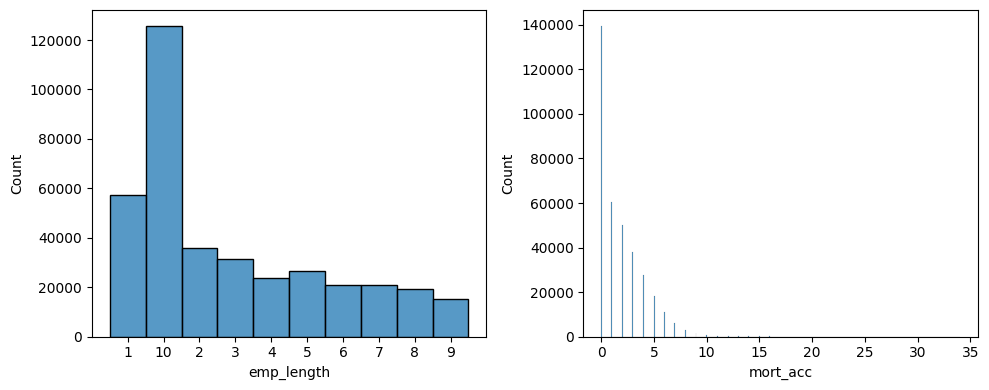

In [117]:
fig,axs=plt.subplots(1,2,figsize=(10,4))
sns.histplot(ax=axs[0],data=df,x='emp_length')
sns.histplot(ax=axs[1],data=df,x='mort_acc')
fig.tight_layout()
plt.show()

## mort_acc is the number of mortgae accounts out of the total_acc. So I will replace the null values with "mode" of mort_acc for different total_acc
## For emp_length, I will use knn imputer to fill the missing data

In [118]:
mode_mort_acc_df=df.groupby('total_acc')['mort_acc'].agg(lambda x: pd.Series.mode(x)[0])
def fill_mort_acc(total_acc, mort_acc):
    if np.isnan(mort_acc):
        return mode_mort_acc_df[total_acc]
    else:
        return mort_acc

df['mort_acc'] = df.apply(lambda x: fill_mort_acc(x['total_acc'],x['mort_acc']), axis=1)

In [119]:
from sklearn.impute import KNNImputer


In [120]:
from sklearn.impute import SimpleImputer

# Fill with median (or mean if more appropriate)
imputer = SimpleImputer(strategy='median')
df['emp_length'] = imputer.fit_transform(df[['emp_length']])
df['emp_length'] = df['emp_length'].round().astype('int').astype('category')



In [121]:
df.isna().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
emp_length,0
home_ownership,0
annual_inc,0
verification_status,0
issue_d,0


# Detecting outliers

In [122]:
#Outliers for every continuous variable

In [123]:
# helper function to detect outliers using IQR method
def detectOutliers_iqr(df):
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    iqr = q3-q1
    lower_outliers = df[df<(q1-1.5*iqr)]
    higher_outliers = df[df>(q3+1.5*iqr)]
    return lower_outliers, higher_outliers

In [124]:
# helper function to detect outliers using standard deviation method
def detectOutliers_std(df):
    mean = df.mean()
    std = df.std()
    upper_limit = mean+(3*std)
    lower_limit = mean-(3*std)
    lower_outliers = df[df<lower_limit]
    higher_outliers = df[df>upper_limit]
    return lower_outliers, higher_outliers

In [125]:
numerical_columns = df.select_dtypes(include=np.number).columns
column_outlier_dictionary = {}
for column in numerical_columns:
    lower_outliers, higher_outliers = detectOutliers_iqr(df[column])
    column_outlier_dictionary[column] = [lower_outliers, higher_outliers]

In [126]:
for key, value in column_outlier_dictionary.items():
    print(f'The column \'{key}\' has {len(value[0]) + len(value[1])} outliers')

The column 'loan_amnt' has 190 outliers
The column 'int_rate' has 3144 outliers
The column 'installment' has 11114 outliers
The column 'annual_inc' has 16649 outliers
The column 'dti' has 275 outliers
The column 'open_acc' has 10297 outliers
The column 'pub_rec' has 57730 outliers
The column 'revol_bal' has 21205 outliers
The column 'revol_util' has 12 outliers
The column 'total_acc' has 8491 outliers
The column 'mort_acc' has 6837 outliers
The column 'pub_rec_bankruptcies' has 45111 outliers


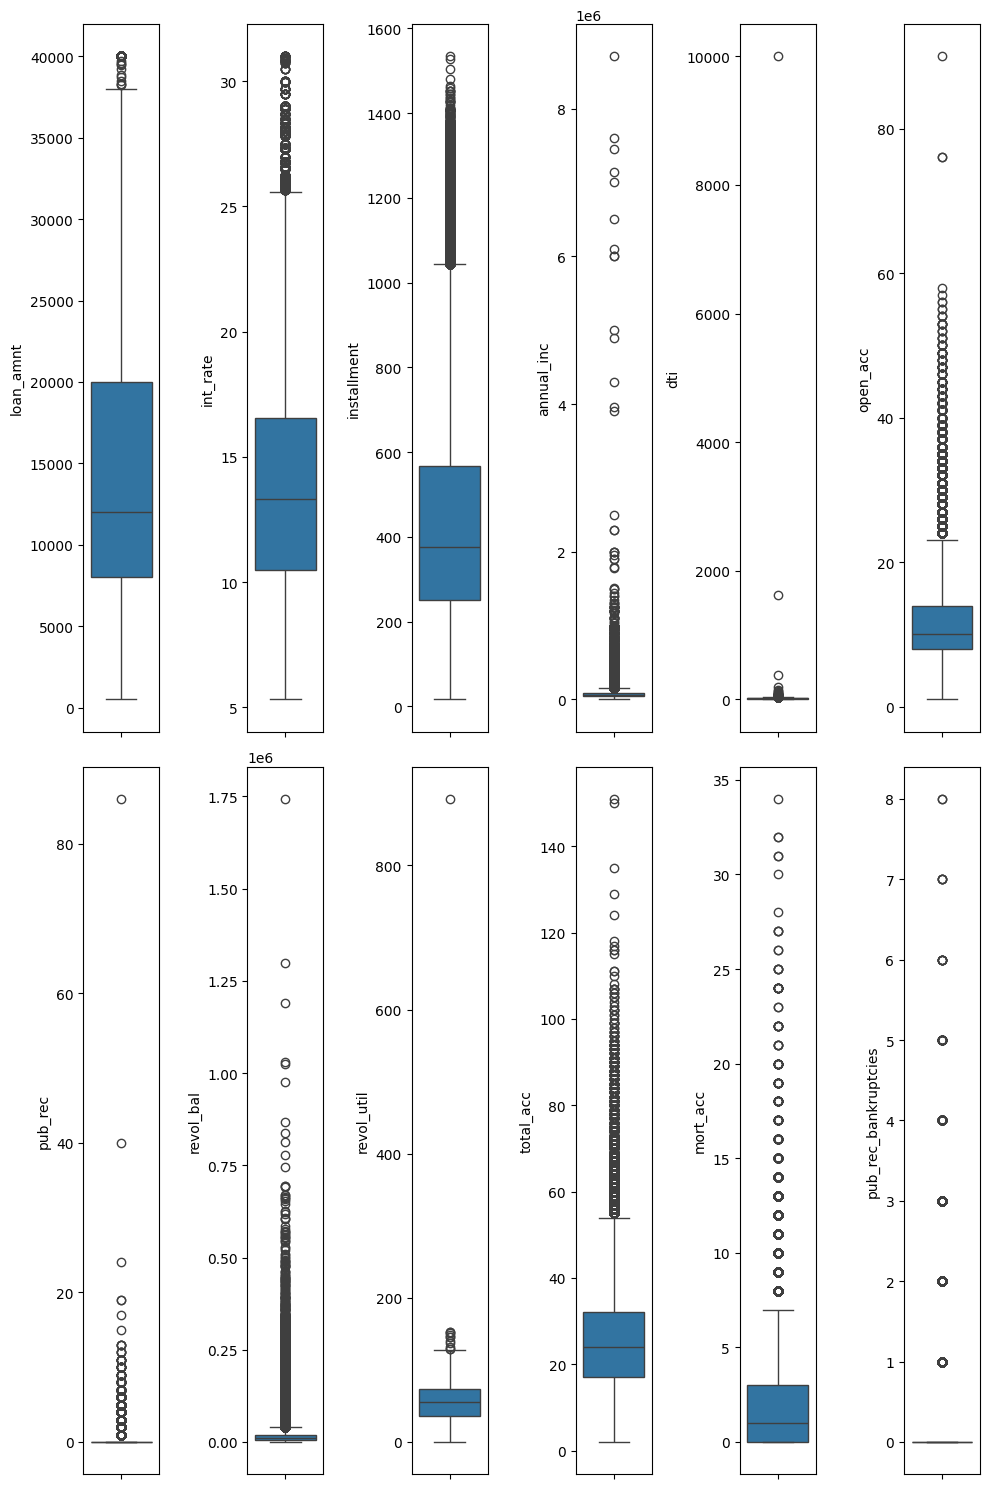

In [127]:
num_cols = 6
num_rows = int(np.ceil(len(numerical_columns)/num_cols))
fig, axs = plt.subplots(num_rows,num_cols,figsize=(10,15))
for idx in range(len(numerical_columns)):
    ax = plt.subplot(num_rows, num_cols, idx+1)
    sns.boxplot(ax = ax, data=df, y = numerical_columns[idx])
plt.tight_layout()
plt.show()

In [128]:
numerical_columns = df.select_dtypes(include=np.number).columns
numerical_columns = list(numerical_columns)
numerical_columns.remove('pub_rec')
numerical_columns.remove('pub_rec_bankruptcies')
numerical_columns = pd.core.indexes.base.Index(numerical_columns)
column_outlier_dictionary = {}
for column in numerical_columns:
    lower_outliers, higher_outliers = detectOutliers_std(df[column])
    column_outlier_dictionary[column] = [lower_outliers, higher_outliers]

In [129]:
for key, value in column_outlier_dictionary.items():
    print(f'The column \'{key}\' has {len(value[0]) + len(value[1])} outliers')

The column 'loan_amnt' has 184 outliers
The column 'int_rate' has 754 outliers
The column 'installment' has 5042 outliers
The column 'annual_inc' has 3190 outliers
The column 'dti' has 12 outliers
The column 'open_acc' has 4873 outliers
The column 'revol_bal' has 4771 outliers
The column 'revol_util' has 16 outliers
The column 'total_acc' has 3396 outliers
The column 'mort_acc' has 6837 outliers


In [130]:
#  Remove the outliers

In [131]:
remove_outliers = True
if True == remove_outliers:
    master_index = pd.core.indexes.base.Index([])
    for key, value in column_outlier_dictionary.items():
        lower_outliers = value[0]
        higher_outliers = value[1]
        master_index = master_index.union(lower_outliers.index).union(higher_outliers.index)
    df.drop(master_index, inplace=True)
else:
    print('Not removing any outliers')

In [132]:
df['pub_rec'].value_counts()

,count
pub_rec,
0.0,315552
1.0,47129
2.0,5107
3.0,1424
4.0,481
5.0,218
6.0,108
7.0,47
8.0,31


In [133]:
df['pub_rec_bankruptcies'].value_counts()

,count
pub_rec_bankruptcies,
0.0,327200
1.0,40774
2.0,1716
3.0,332
4.0,75
5.0,30
6.0,6
7.0,4
8.0,2


In [134]:
df = df[df['pub_rec'] < 11]
df = df[df['pub_rec_bankruptcies'] < 6]

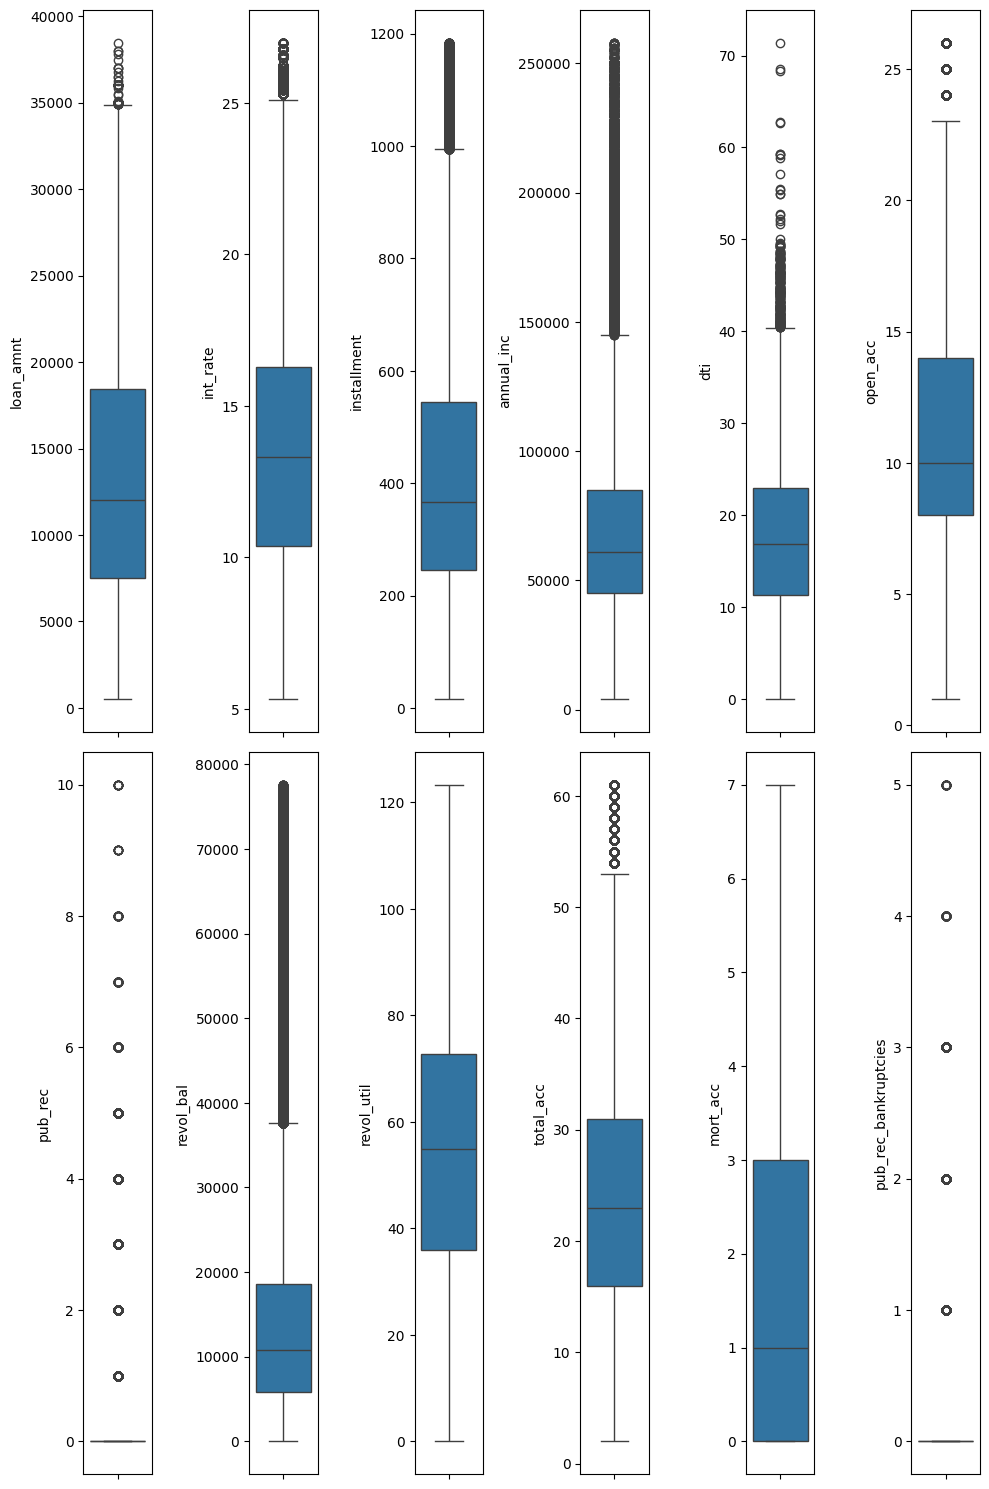

In [135]:
numerical_columns = df.select_dtypes(include=np.number).columns
num_cols = 6
num_rows = int(np.ceil(len(numerical_columns)/num_cols))
fig, axs = plt.subplots(num_rows,num_cols,figsize=(10,15))
for idx in range(len(numerical_columns)):
    ax = plt.subplot(num_rows, num_cols, idx+1)
    sns.boxplot(ax = ax, data=df, y = numerical_columns[idx])
plt.tight_layout()
plt.show()

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 370106 entries, 0 to 396029
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   loan_amnt             370106 non-null  float64       
 1   term                  370106 non-null  category      
 2   int_rate              370106 non-null  float64       
 3   installment           370106 non-null  float64       
 4   grade                 370106 non-null  category      
 5   emp_length            370106 non-null  category      
 6   home_ownership        370106 non-null  category      
 7   annual_inc            370106 non-null  float64       
 8   verification_status   370106 non-null  category      
 9   issue_d               370106 non-null  datetime64[ns]
 10  loan_status           370106 non-null  category      
 11  purpose               370106 non-null  category      
 12  dti                   370106 non-null  float64       
 13  earl

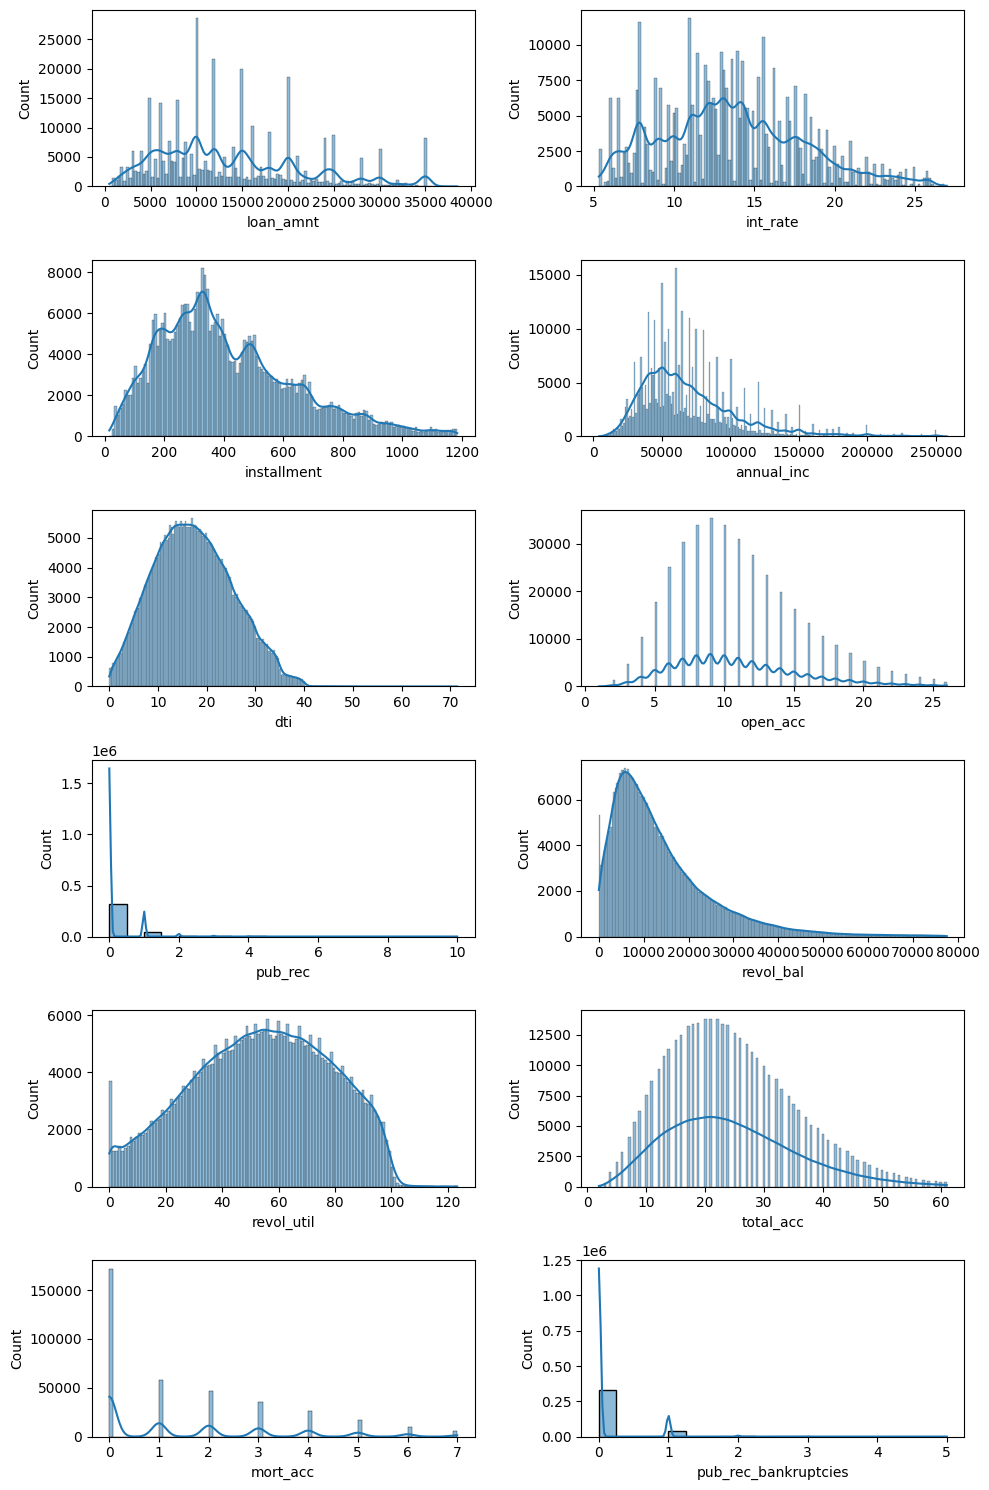

In [137]:
# Univariate analysis
num_cols = 2
num_rows = int(np.ceil(len(numerical_columns)/num_cols))
fig, axs = plt.subplots(num_rows,num_cols,figsize=(10,15))
for idx in range(len(numerical_columns)):
    ax = plt.subplot(num_rows, num_cols, idx+1)
    sns.histplot(ax = ax, data=df, x = numerical_columns[idx], kde=True)
plt.tight_layout()
plt.show()

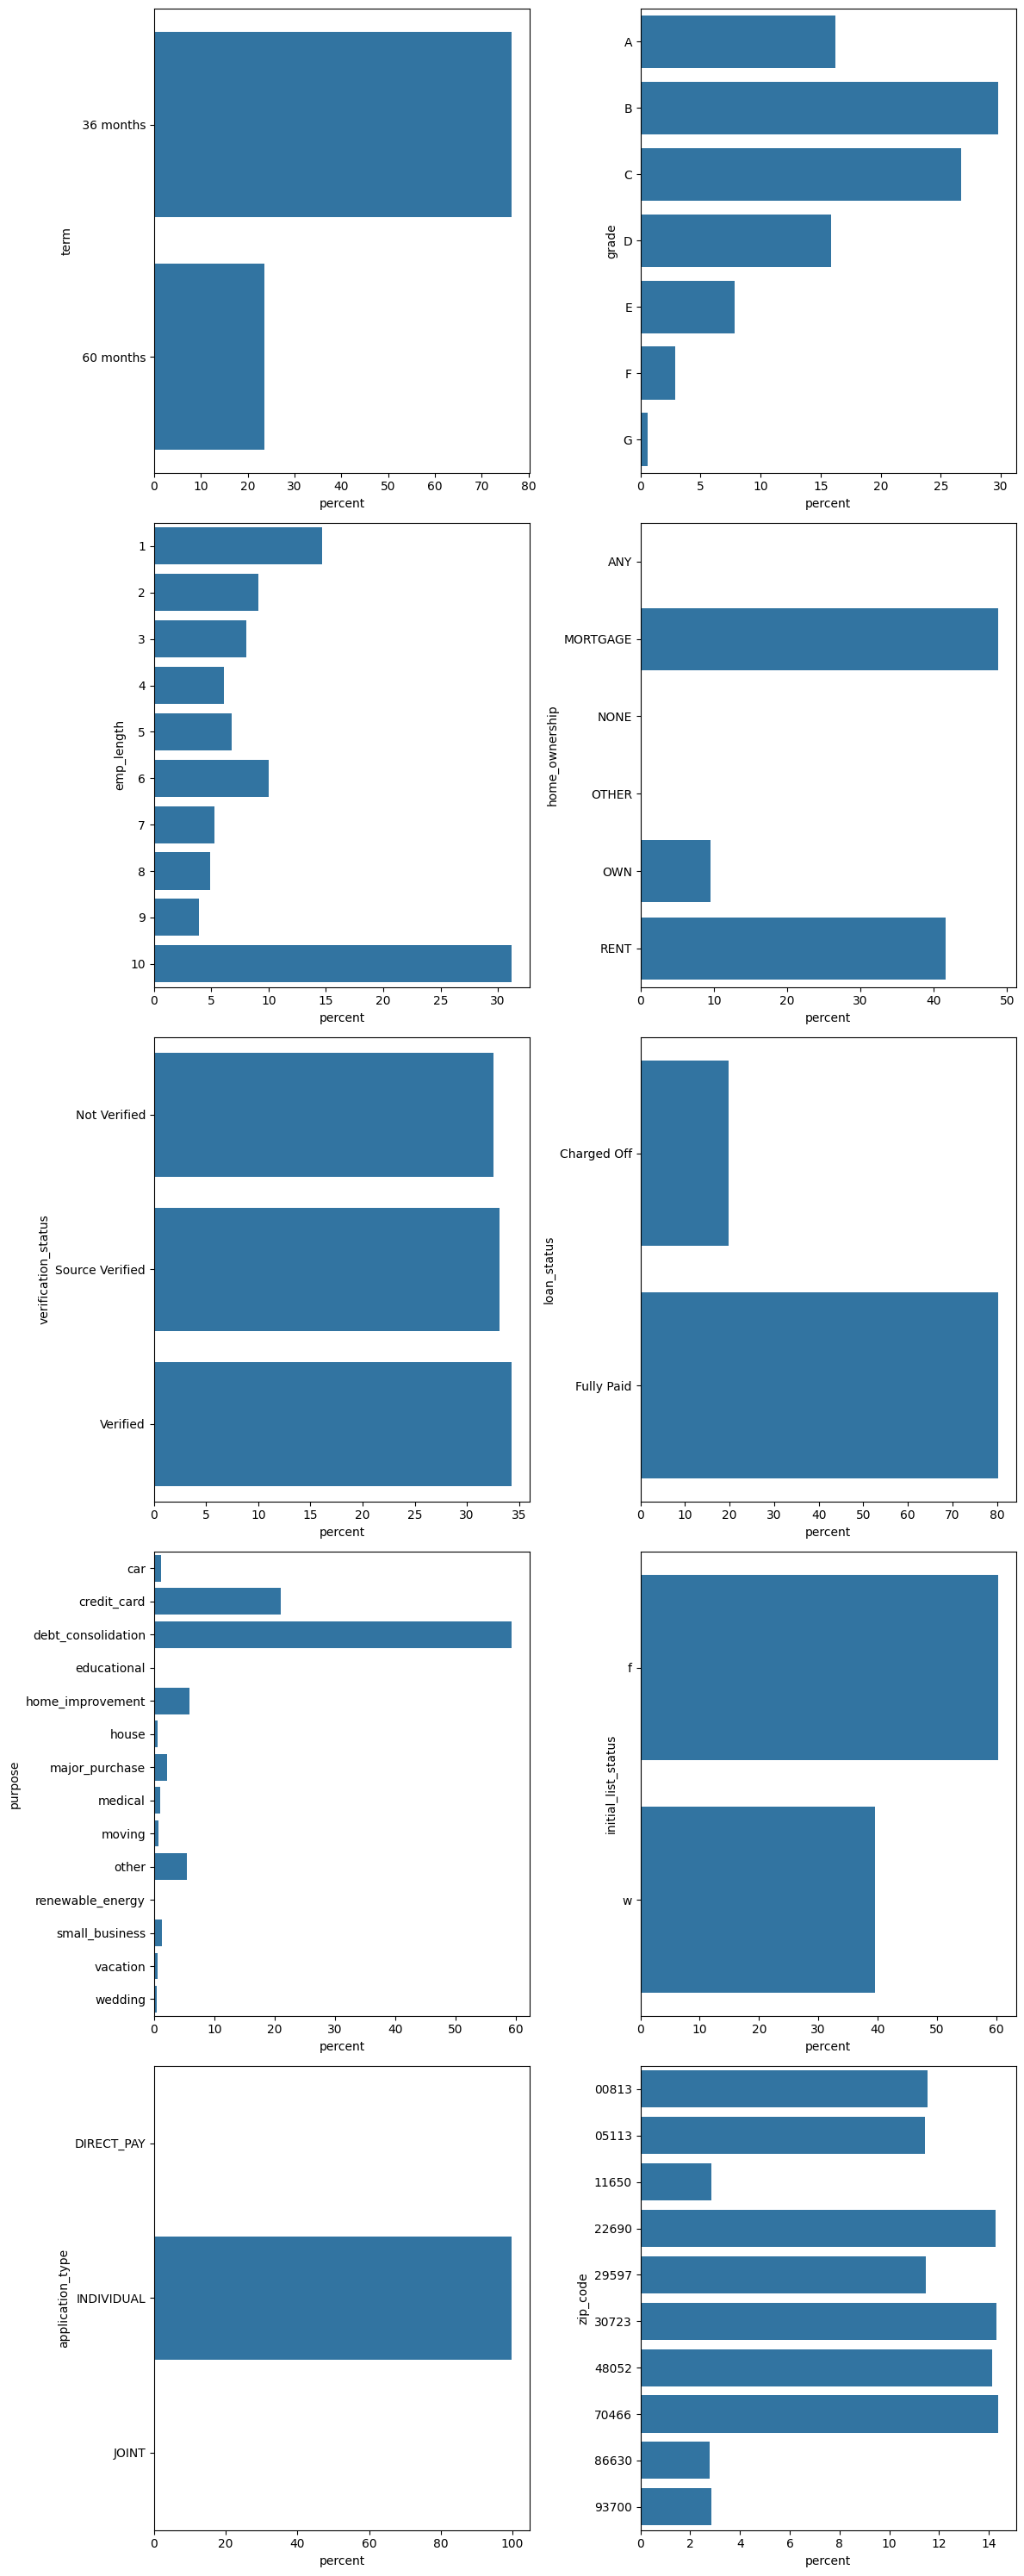

In [138]:
# Categorical Variables
categorical_columns = df.select_dtypes(include='category').columns
num_cols = 2
num_rows = int(np.ceil(len(categorical_columns)/num_cols))
fig, axs = plt.subplots(num_rows,num_cols,figsize=(12,30))
for idx in range(len(categorical_columns)):
    ax = plt.subplot(num_rows, num_cols, idx+1)
    sns.countplot(ax = ax, data=df, y = categorical_columns[idx], stat='percent')
plt.tight_layout()
plt.show()

In [139]:
# Bivariate analysis

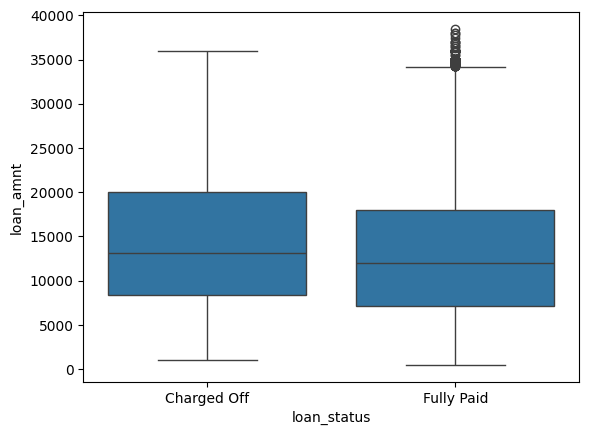

In [140]:
sns.boxplot(data=df, x='loan_status', y='loan_amnt')
plt.show()

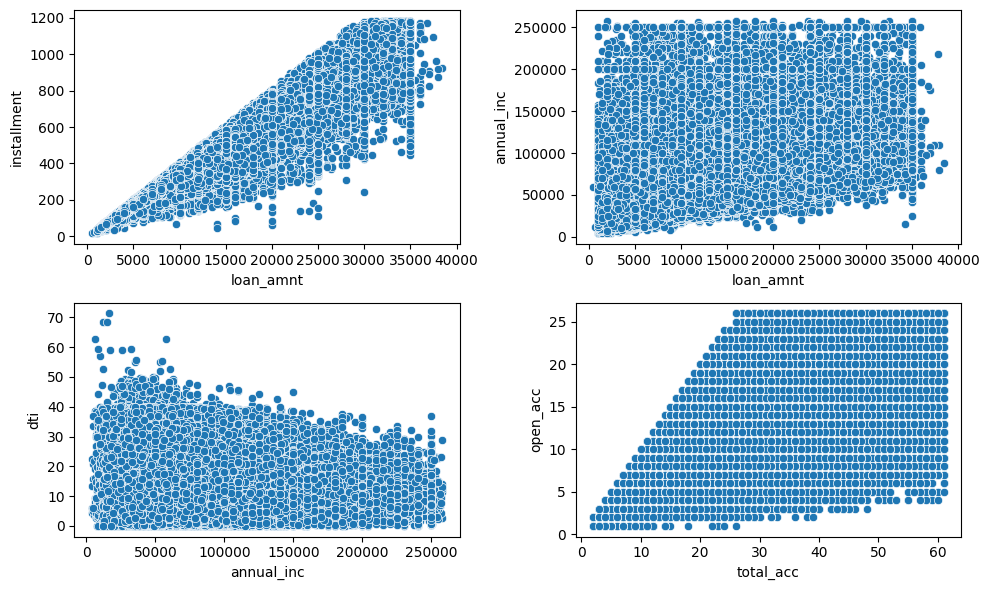

In [141]:
fig, axs = plt.subplots(2,2,figsize=(10,6))
sns.scatterplot(ax=axs[0,0], data=df, x='loan_amnt', y='installment')
sns.scatterplot(ax=axs[0,1], data=df, x='loan_amnt', y='annual_inc')
sns.scatterplot(ax=axs[1,0], data=df, x='annual_inc', y='dti')
sns.scatterplot(ax=axs[1,1], data=df, x='total_acc', y='open_acc')
fig.tight_layout()
plt.show()

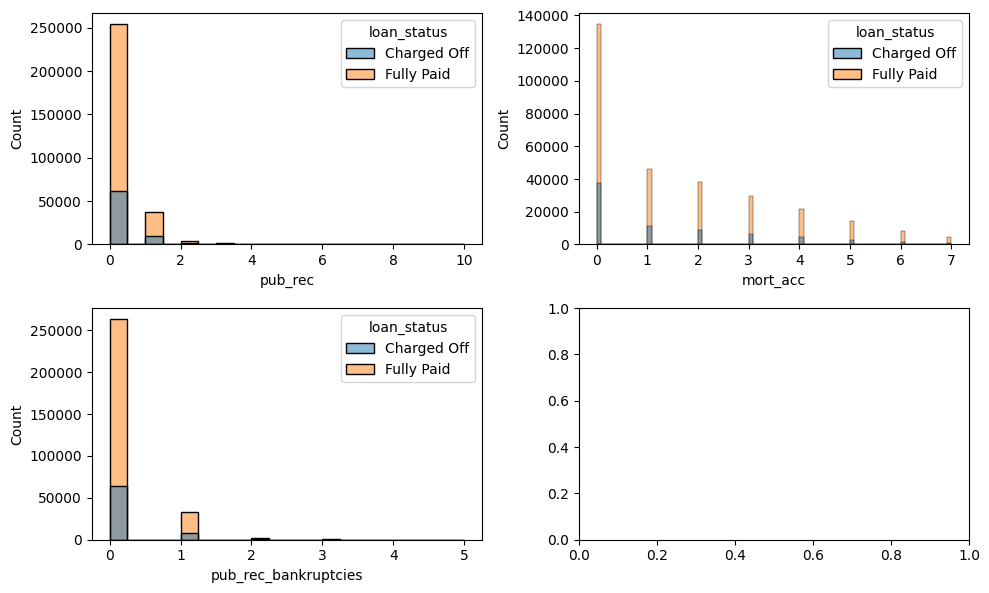

In [142]:
fig, axs = plt.subplots(2,2,figsize=(10,6))
sns.histplot(ax=axs[0,0], data=df, x='pub_rec', hue='loan_status')
sns.histplot(ax=axs[0,1], data=df, x='mort_acc', hue='loan_status')
sns.histplot(ax=axs[1,0], data=df, x='pub_rec_bankruptcies', hue='loan_status')
fig.tight_layout()
plt.show()

In [143]:
group_0_list = [0.0]
pub_rec_list = list(df['pub_rec'].explode().unique())
group_1_list = list(set(pub_rec_list) - set(group_0_list))
df['any_neg_rec'] = df['pub_rec'].replace(group_0_list, 0)
df['any_neg_rec'] = df['any_neg_rec'].replace(group_1_list, 1)
df['any_neg_rec'] = df['any_neg_rec'].astype('category')

group_0_list = [0.0]
pub_rec_list = list(df['mort_acc'].explode().unique())
group_1_list = list(set(pub_rec_list) - set(group_0_list))
df['any_mort'] = df['mort_acc'].replace(group_0_list, 0)
df['any_mort'] = df['any_mort'].replace(group_1_list, 1)
df['any_mort'] = df['any_mort'].astype('category')

group_0_list = [0.0]
pub_rec_list = list(df['pub_rec_bankruptcies'].explode().unique())
group_1_list = list(set(pub_rec_list) - set(group_0_list))
df['any_bankruptcies'] = df['pub_rec_bankruptcies'].replace(group_0_list, 0)
df['any_bankruptcies'] = df['any_bankruptcies'].replace(group_1_list, 1)
df['any_bankruptcies'] = df['any_bankruptcies'].astype('category')

df.drop(columns = ['pub_rec', 'mort_acc', 'pub_rec_bankruptcies'], inplace=True)

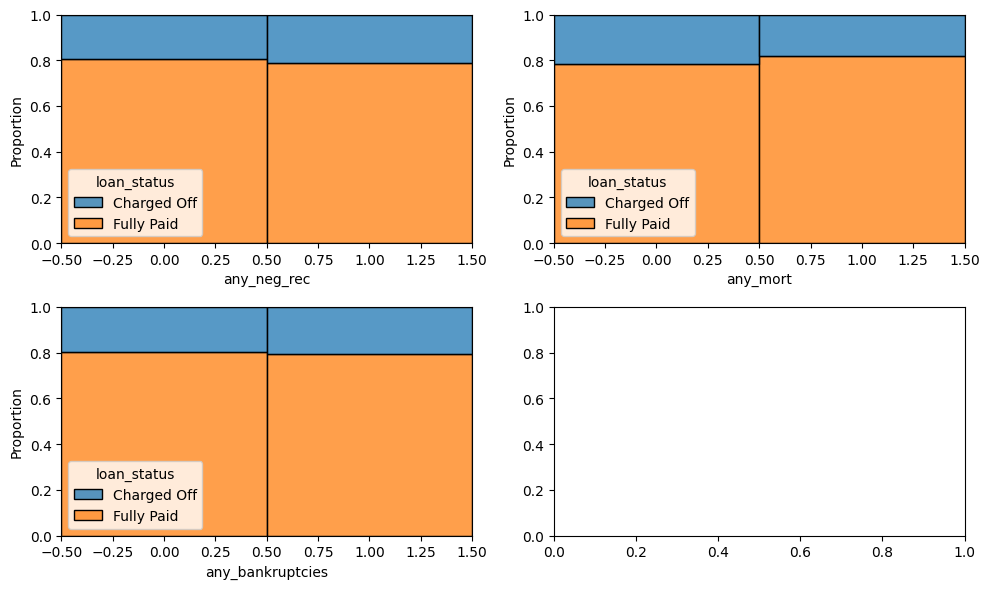

In [144]:
fig, axs = plt.subplots(2,2,figsize=(10,6))
sns.histplot(ax=axs[0,0], data=df, x='any_neg_rec', hue='loan_status', stat="proportion", multiple="fill")
sns.histplot(ax=axs[0,1], data=df, x='any_mort', hue='loan_status', stat="proportion", multiple="fill")
sns.histplot(ax=axs[1,0], data=df, x='any_bankruptcies', hue='loan_status', stat="proportion", multiple="fill")
fig.tight_layout()
plt.show()

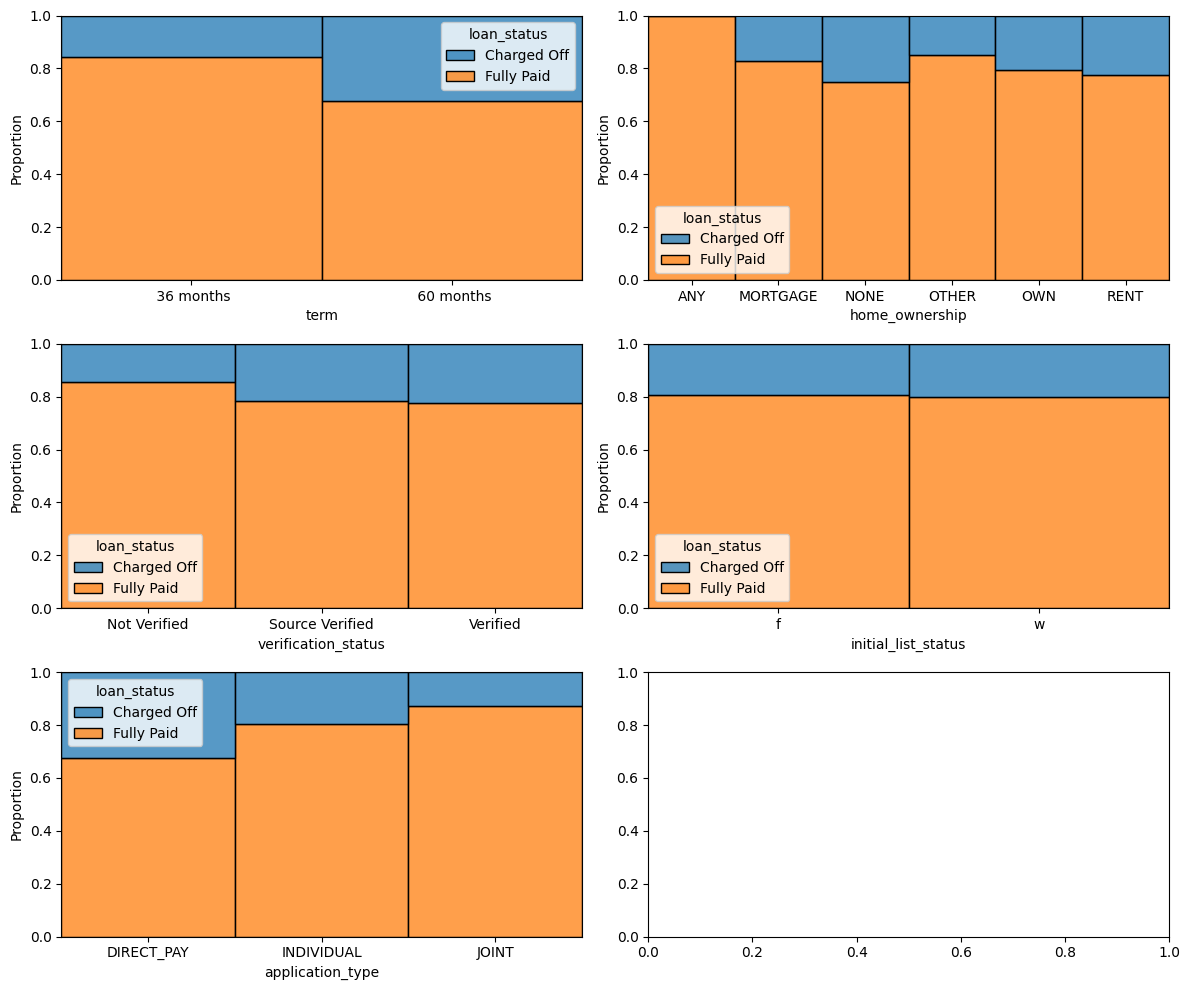

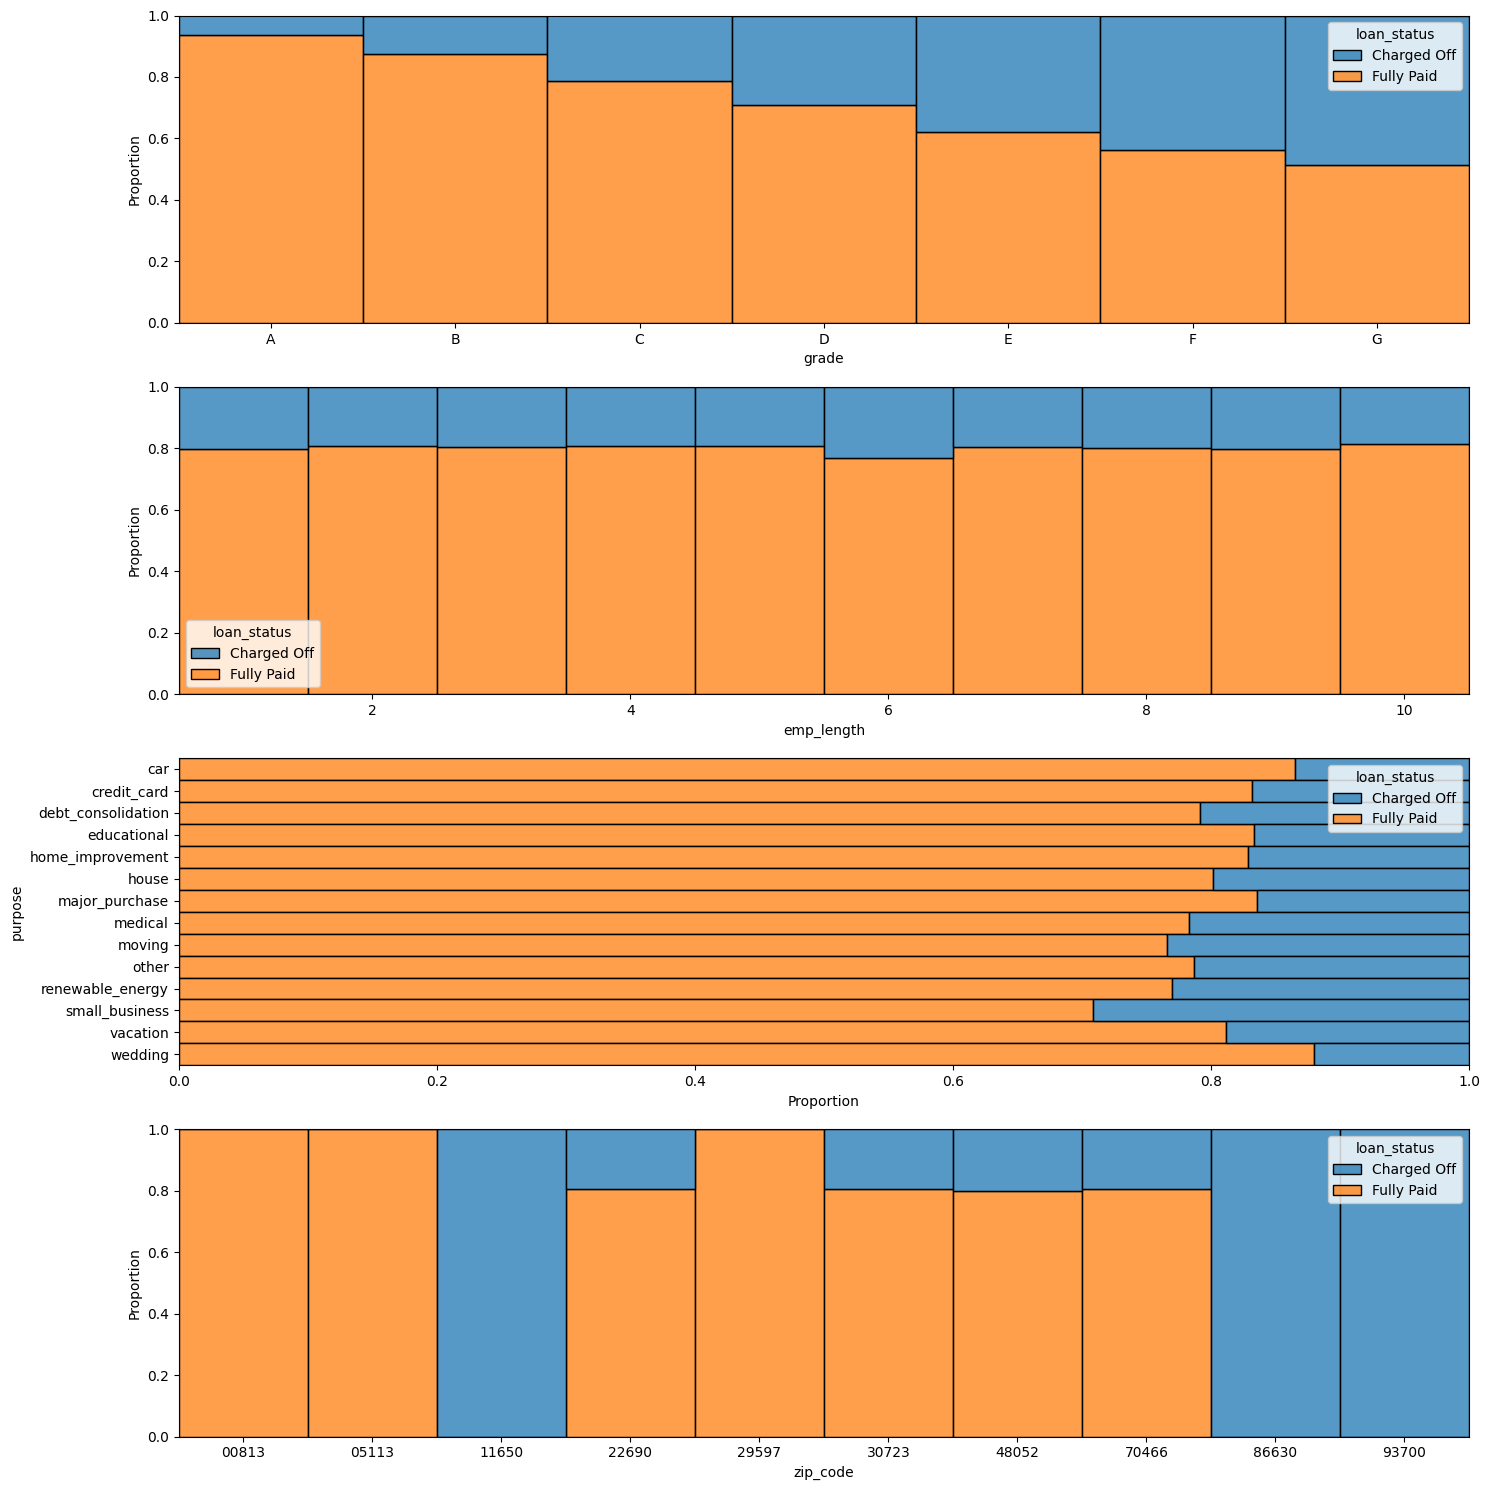

In [145]:
fig, axs = plt.subplots(3,2,figsize=(12,10))
sns.histplot(ax=axs[0,0], data=df, x='term', hue='loan_status', stat="proportion", multiple="fill")
sns.histplot(ax=axs[0,1], data=df, x='home_ownership', hue='loan_status', stat="proportion", multiple="fill")
sns.histplot(ax=axs[1,0], data=df, x='verification_status', hue='loan_status', stat="proportion", multiple="fill")
sns.histplot(ax=axs[1,1], data=df, x='initial_list_status', hue='loan_status', stat="proportion", multiple="fill")
sns.histplot(ax=axs[2,0], data=df, x='application_type', hue='loan_status', stat="proportion", multiple="fill")
fig.tight_layout()
plt.show()

fig, axs = plt.subplots(4,1,figsize=(15,15))
sns.histplot(ax=axs[0], data=df, x='grade', hue='loan_status', stat="proportion", multiple="fill")
sns.histplot(ax=axs[1], data=df, x='emp_length', hue='loan_status', stat="proportion", multiple="fill")
sns.histplot(ax=axs[2], data=df, y='purpose', hue='loan_status', stat="proportion", multiple="fill")
sns.histplot(ax=axs[3], data=df, x='zip_code', hue='loan_status', stat="proportion", multiple="fill")
fig.tight_layout()
plt.show()

In [146]:
df.drop(columns=['any_neg_rec', 'any_bankruptcies', 'initial_list_status', 'emp_length'], inplace=True)

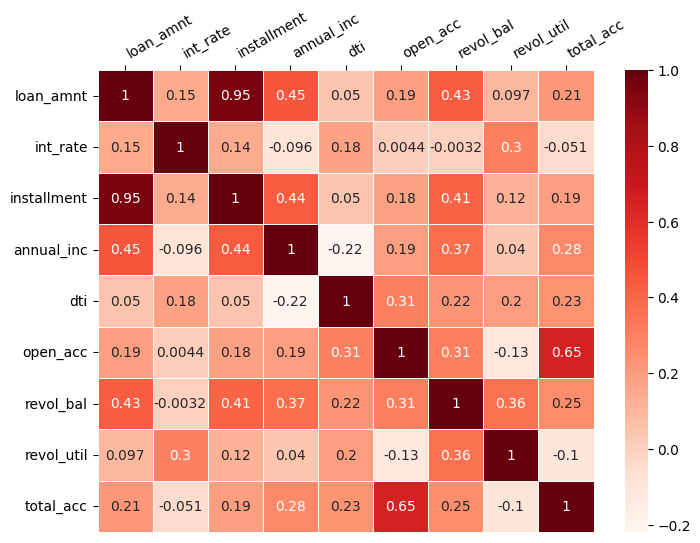

In [147]:
#Multivariate analysis
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, linewidth=0.5, cmap = "Reds", ax=ax)
ax.xaxis.tick_top()
plt.xticks(rotation=30, ha='left')
plt.show()

1. loan amount is highly correlated with installment
2. There is good correlation between loan amount - annual income, loan amount - revol balance, installment - annual income, installment - revol balance, open account - total account

In [148]:
df.drop(columns=['issue_d', 'earliest_cr_line'], inplace=True)

In [149]:
# Multicollinearity Check

In [150]:
features_df = df.drop(columns=['loan_status']) # Drop target column
features_df.select_dtypes(include='category').columns
features_df = features_df.drop(columns=features_df.select_dtypes(include='category').columns) # Drop category columns
features_df = sm.add_constant(features_df)  # Adding a constant column for the intercept
vif_df = pd.DataFrame()
vif_df['Features'] = features_df.columns
vif_df['VIF'] = [variance_inflation_factor(features_df.values, idx) for idx in range(len(features_df.columns))]
vif_df['VIF'] = round(vif_df['VIF'], 2)
vif_df = vif_df.sort_values(by='VIF', ascending=False)
vif_df

,Features,VIF
0,const,24.91
1,loan_amnt,11.58
3,installment,11.04
6,open_acc,2.00
9,total_acc,1.87
7,revol_bal,1.76
4,annual_inc,1.62
8,revol_util,1.47
5,dti,1.40
2,int_rate,1.23


**loan amount is highly correlated with installment which is also shown here by high VIF values. I will drop installment**

In [151]:
features_df = features_df.drop(columns=['installment'])
features_df = sm.add_constant(features_df)  # Adding a constant column for the intercept
vif_df = pd.DataFrame()
vif_df['Features'] = features_df.columns
vif_df['VIF'] = [variance_inflation_factor(features_df.values, idx) for idx in range(len(features_df.columns))]
vif_df['VIF'] = round(vif_df['VIF'], 2)
vif_df = vif_df.sort_values(by='VIF', ascending=False)
vif_df

,Features,VIF
0,const,24.76
5,open_acc,2.00
8,total_acc,1.86
6,revol_bal,1.75
3,annual_inc,1.62
1,loan_amnt,1.49
7,revol_util,1.46
4,dti,1.40
2,int_rate,1.22


In [152]:
df.drop(columns=['installment'], inplace=True)

In [153]:
# Encode categorical variables

In [154]:
final_df = df.copy()
final_df.reset_index(inplace=True, drop=True)

In [155]:
X = final_df.drop(columns=['loan_status'])
y = final_df['loan_status']

In [156]:
y = y.replace({'Fully Paid': 0, 'Charged Off': 1}).astype(int)

/tmp/ipython-input-156-1592694047.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'Fully Paid': 0, 'Charged Off': 1}).astype(int)
/tmp/ipython-input-156-1592694047.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y = y.replace({'Fully Paid': 0, 'Charged Off': 1}).astype(int)


In [157]:
# Clean 'term'
X['term'] = X['term'].astype(str).str.lower().str.strip()
X['term'] = X['term'].replace({'short': 0, 'long': 1})
X['term'] = pd.to_numeric(X['term'], errors='coerce').fillna(0).astype('int8')

# Clean 'any_mort'
X['any_mort'] = X['any_mort'].replace({'yes': 1, 'no': 0, 'Y': 1, 'N': 0})
X['any_mort'] = pd.to_numeric(X['any_mort'], errors='coerce').fillna(0).astype('int8')



In [158]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370106 entries, 0 to 370105
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   loan_amnt            370106 non-null  float64 
 1   term                 370106 non-null  int8    
 2   int_rate             370106 non-null  float64 
 3   grade                370106 non-null  category
 4   home_ownership       370106 non-null  category
 5   annual_inc           370106 non-null  float64 
 6   verification_status  370106 non-null  category
 7   purpose              370106 non-null  category
 8   dti                  370106 non-null  float64 
 9   open_acc             370106 non-null  float64 
 10  revol_bal            370106 non-null  float64 
 11  revol_util           370106 non-null  float64 
 12  total_acc            370106 non-null  float64 
 13  application_type     370106 non-null  category
 14  zip_code             370106 non-null  category
 15  

In [159]:
categorical_columns = X.select_dtypes(include='category').columns
categorical_columns

Index(['grade', 'home_ownership', 'verification_status', 'purpose',
       'application_type', 'zip_code'],
      dtype='object')

In [160]:
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(X[categorical_columns])
encoded_df = pd.DataFrame(encoded_data, columns = encoder.get_feature_names_out(categorical_columns))
X = pd.concat([X, encoded_df], axis=1)
X.drop(columns = categorical_columns, inplace=True)
X.head()

,loan_amnt,term,int_rate,annual_inc,dti,open_acc,revol_bal,revol_util,total_acc,any_mort,...,zip_code_00813,zip_code_05113,zip_code_11650,zip_code_22690,zip_code_29597,zip_code_30723,zip_code_48052,zip_code_70466,zip_code_86630,zip_code_93700
0,10000.0,0,11.44,117000.0,26.24,16.0,36369.0,41.8,25.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,8000.0,0,11.99,65000.0,22.05,17.0,20131.0,53.3,27.0,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,15600.0,0,10.49,43057.0,12.79,13.0,11987.0,92.2,26.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7200.0,0,6.49,54000.0,2.60,6.0,5472.0,21.5,13.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,24375.0,0,17.27,55000.0,33.95,13.0,24584.0,69.8,43.0,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [161]:
# Train-test split

In [162]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((296084, 53), (74022, 53), (296084,), (74022,))

In [163]:
X_train.head()

,loan_amnt,term,int_rate,annual_inc,dti,open_acc,revol_bal,revol_util,total_acc,any_mort,...,zip_code_00813,zip_code_05113,zip_code_11650,zip_code_22690,zip_code_29597,zip_code_30723,zip_code_48052,zip_code_70466,zip_code_86630,zip_code_93700
133405,27000.0,0,16.29,82302.0,25.52,13.0,12014.0,48.6,29.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
365868,6000.0,0,18.55,45000.0,19.37,8.0,3219.0,73.2,11.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
71124,8975.0,0,9.71,65000.0,7.98,10.0,3932.0,34.5,58.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
33923,9600.0,0,6.62,58000.0,25.01,10.0,57236.0,36.3,19.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
30512,18000.0,0,11.53,75000.0,8.50,9.0,9916.0,35.8,17.0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [164]:
min_max_scaler = MinMaxScaler()
# Fit min_max_scaler to training data
min_max_scaler.fit(X_train)
# Scale the training and testing data
X_train = pd.DataFrame(min_max_scaler.transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(min_max_scaler.transform(X_test), columns=X_test.columns)

In [165]:
y_train.value_counts(normalize=True)*100

,proportion
loan_status,
0,80.249186
1,19.750814


In [166]:
sm = SMOTE(random_state=0)
X_train, y_train = sm.fit_resample(X_train, y_train)
y_train.value_counts(normalize=True)*100

,proportion
loan_status,
0,50.0
1,50.0


In [167]:
# Build Logistic Regression model
model = LogisticRegression(solver='lbfgs', max_iter=300)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)

In [168]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80    237605
           1       0.80      0.82      0.81    237605

    accuracy                           0.80    475210
   macro avg       0.80      0.80      0.80    475210
weighted avg       0.80      0.80      0.80    475210



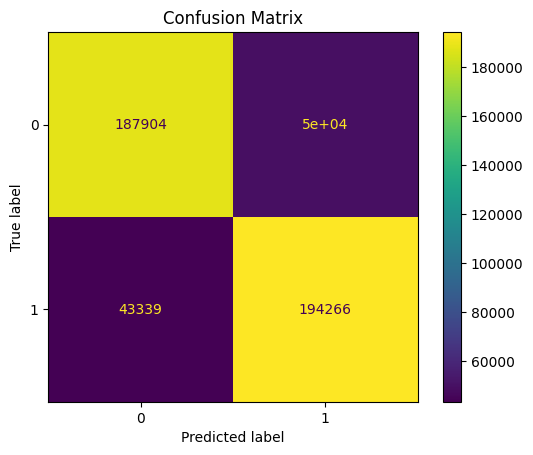

In [169]:
# Confusion Matrix
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

In [170]:
y_test_pred = model.predict(X_test)

In [171]:
#Classification metrics and confusion matrix for Testing data

In [172]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.95      0.79      0.86     59619
           1       0.48      0.81      0.61     14403

    accuracy                           0.80     74022
   macro avg       0.72      0.80      0.73     74022
weighted avg       0.86      0.80      0.81     74022



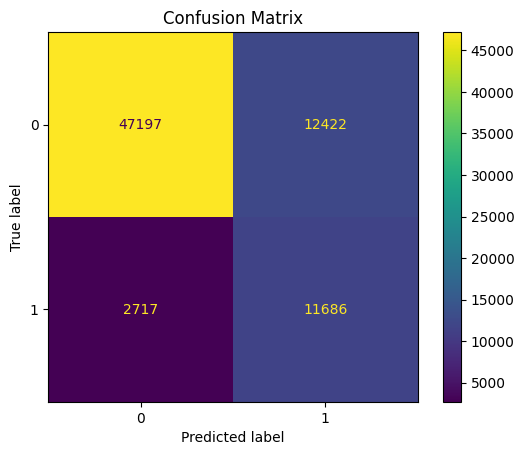

In [173]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

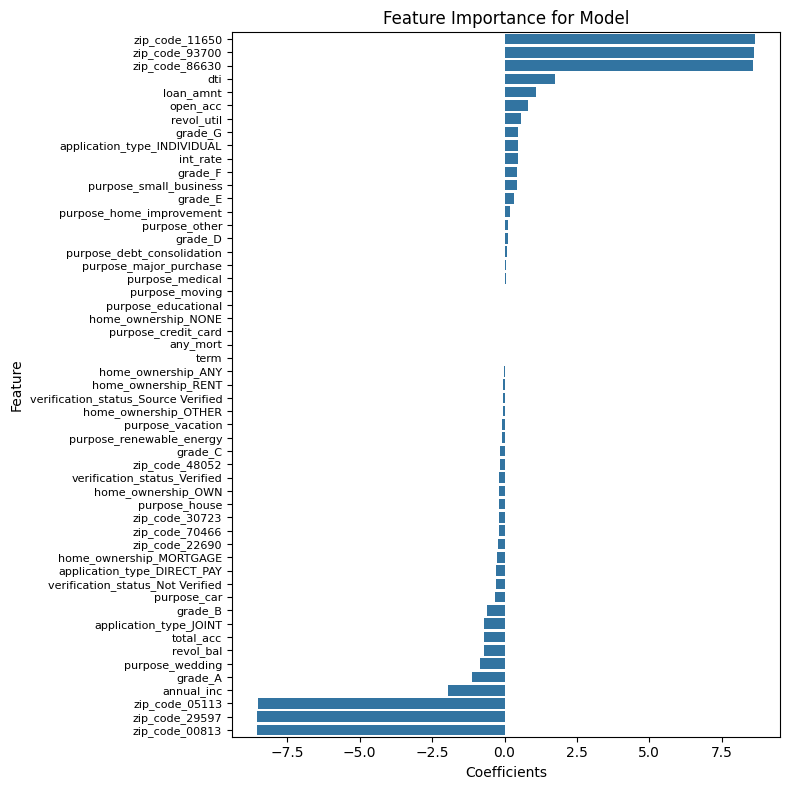

In [174]:
feature_imp = pd.DataFrame({'Columns':X_train.columns, 'Coefficients':model.coef_[0]}).round(2).sort_values('Coefficients', ascending=False)

plt.figure(figsize=(8,8))
sns.barplot(data=feature_imp, y = 'Columns', x =  'Coefficients')
plt.title("Feature Importance for Model")
plt.yticks(fontsize=8)
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



##The features zip_code_29597, zip_code_05113, zip_code_00813, annual_inc and application_type_joint have got high positive weightage and features zip_code_86630, zip_code_11650, zip_code_93700, dti and open_acc have got high negative weightage indicating their major contribution towards target variable




In [175]:
# ROC and AUC

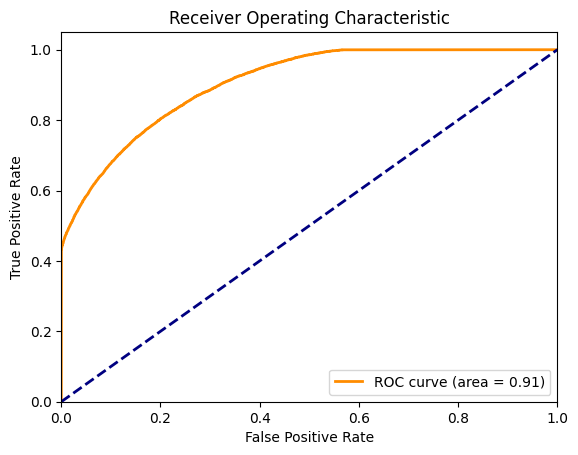

In [176]:
# Predict probabilities for the test set
probs = model.predict_proba(X_test)[:,1]

# Compute the false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, probs)

# Compute the area under the ROC curve
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# ROC curve illustrates the trade off between TPR(True Positive Rate) and FPR(False Positive Rate) for various thresholds
#The AU-ROC value of 0.91 signifies that the model is able to differenciate well between the two classes
#Let us also look at PR Curve(Precision Recall Curve)






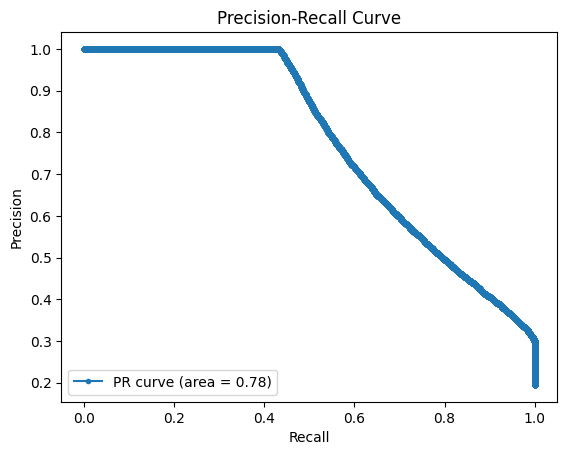

In [177]:
precision, recall, thr = precision_recall_curve(y_test, probs)

# Area under Precision Recall Curve
apc = average_precision_score(y_test, probs)

# Plot the precision-recall curve
plt.plot(recall, precision, marker='.', label='PR curve (area = %0.2f)' % apc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

#PR curve illustrates the trade off between Precision and Recall for various thresholds
#The model has a AU-PRC value of 0.78 which is not that high. It is better than the random model which has a AU-PRC value of 0.5.
#This clearly indicates that we simply cannot conclude on the model's performance from just the ROC curve.


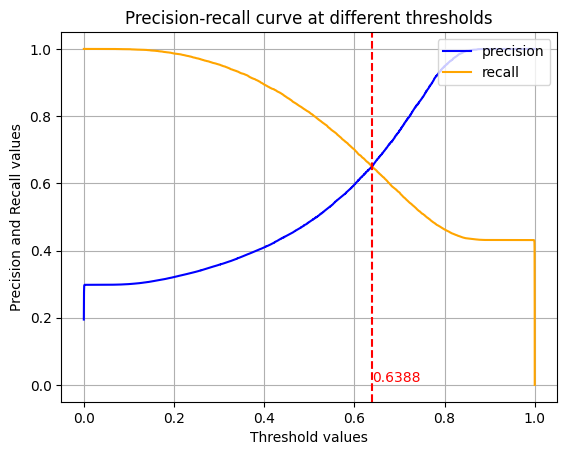

In [178]:
plt.figure()
plt.plot(thr,precision[0:len(thr)],label='precision',color='blue')
plt.plot(thr,recall[0:len(thr)],label='recall',color='orange')
intersection_thr = thr[np.where(precision == recall)[0][0]].round(4)
plt.axvline(intersection_thr, linestyle='--', color='red')
plt.text(intersection_thr, 0.01, str(intersection_thr), ha='left', color='red')
plt.title("Precision-recall curve at different thresholds")
plt.xlabel("Threshold values")
plt.ylabel("Precision and Recall values")
plt.legend(loc="upper right")
plt.grid()
plt.show()

In [179]:
y_pred = model.predict_proba(X_test)[:,1]
threshold_considered = intersection_thr
y_pred_custom = (y_pred>threshold_considered).astype('int')
print(classification_report(y_test,y_pred_custom))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92     59619
           1       0.65      0.65      0.65     14403

    accuracy                           0.86     74022
   macro avg       0.78      0.78      0.78     74022
weighted avg       0.86      0.86      0.86     74022



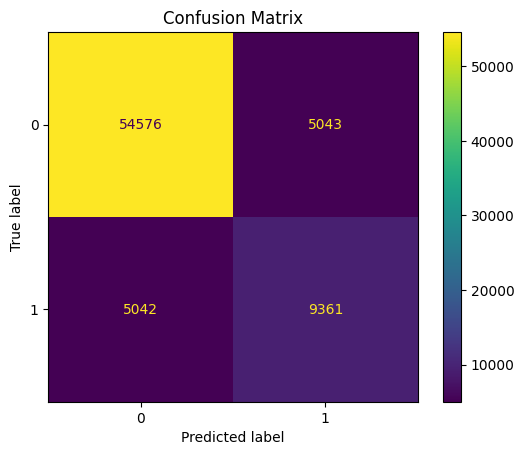

In [180]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_custom)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

# With the new threshold, precision for class 1 (defaulters) has increased at a cost of decrease in Recall
#The overall F1-score and accuracy has increased

- **80%** of the customers have fully paid their loan and 20% are defaulters
- Loan amount and installment are highly **correlated** as it is obvious that high loan amount will have high installment amount
- Loan taken for short term, i.e. **3 years** are most likely to be **fully paid back**
- Most of the people have home ownership as **mortgage**
- Suprisingly, loans which are **not verified** are more likely to be **paid back**
- Loan taken as **joint** application type are more likely to be **paid back**
- People with **grade A** are more likely to fully pay their loan
- Loan taken for **wedding** are more likely to be paid back
- People from zip code **00813,  05113** fully pay back their loans whereas people from zip code **11650, 86630, 93700** are all defaulters
- The features **zip_code_29597, zip_code_05113, zip_code_00813, annual_inc, application_type_joint, zip_code_86630, zip_code_11650, zip_code_93700, dti, open_acc** affected the model outcome heavily
- As per the ROC curve and AU-ROC value of 0.91, the model is able to differenciate well between the defaulters and non-defaulters
- As per the PRC and AU-PRC value of 0.97, the model is able to return accurate results as well as return majority of all positive results(high recall)

In [181]:
# Recommendation

- The bank can provide more short term loans, i.e. for 3 years, without much risk
- Provide more joint loans and scrutinize more individual and direct pay application types
- Analyze carefully the loan applications of customers with grades D, E, F and G. Do not provide them loans or provide smaller loans to these customers
- Reduce the loan given for small bussiness or analyze their application in detail before giving out loan to small bussiness
- Do not provide loans to customers with zip code 11650, 86630, 93700